In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Original data
data = {
    'Station': ['08162501', '08162600', '08164450', '08164503', '08164000', '08164504', '08164600',
                '08164800', '08188810', '08189200', '08189500', '08189700', '08211500',
                '08211520', '08212300', '08212400', '08212820'],
    '5 Yr': [1158.091, 200.36, 275.471, 218.837, 27.7, 95.21, 142.135, 165.326, 134.384, 
             51, 297.47, 162.035, 198.212, 91.37, 14.979, 11.782, 47 ],
    '10 Yr': [1735.945, 246.181, 405.844, 307.105,28.2, 140.297, 243.722, 222.77, 
              151.255, 65.695, 571.208, 308.244, 379.301, 151.787, 19.684, 21.895, 55.648 ],
    '20 Yr': [2424.986, 290.133, 558.895, 406.275, 28.4, 193.237, 380.45, 277.939, 
              165.122, 78.92, 979.018, 524.243, 648.253, 230.82, 24.06, 33.727, 62.981 ],
    '50 Yr': [3532.654, 347.025, 801.203, 556.678,28.6, 277.065, 628.017, 348.717, 
              180.661, 95.074, 1795.366, 953.05, 1184.993, 370, 29.533, 51.008, 71.442],
    '100 Yr':[4540, 390, 1019, 687, 60, 352, 877, 401, 191, 107, 2690, 1420, 1772,
               506, 34, 65, 77]
}

df = pd.DataFrame(data)


In [3]:
sns.set(style="whitegrid")


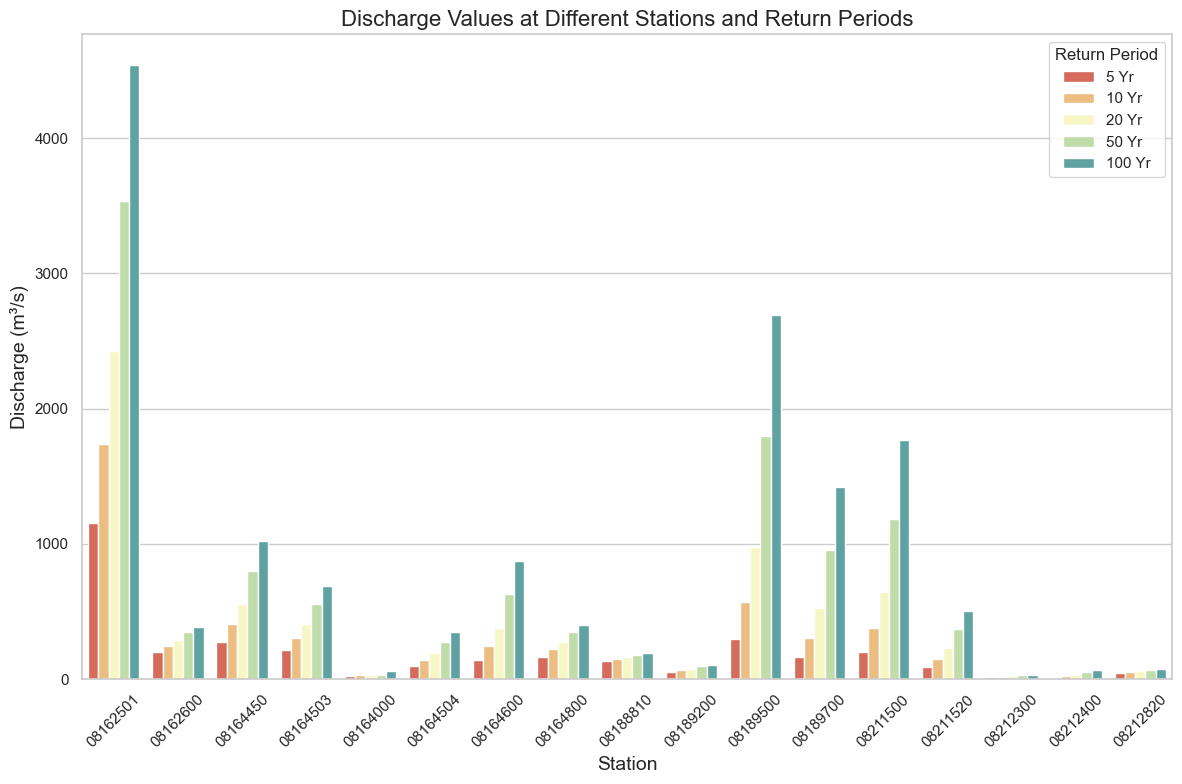

In [4]:
# Melt dataframe to suitable format for seaborn
df_melted = pd.melt(df, id_vars=['Station'], var_name='Return Period', value_name='Discharge')

plt.figure(figsize=(12, 8))
sns.barplot(x='Station', y='Discharge', hue='Return Period', data=df_melted, palette="Spectral")

plt.title('Discharge Values at Different Stations and Return Periods', fontsize=16)
plt.xlabel('Station', fontsize=14)
plt.ylabel('Discharge (m³/s)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Return Period')
plt.tight_layout()
plt.show()


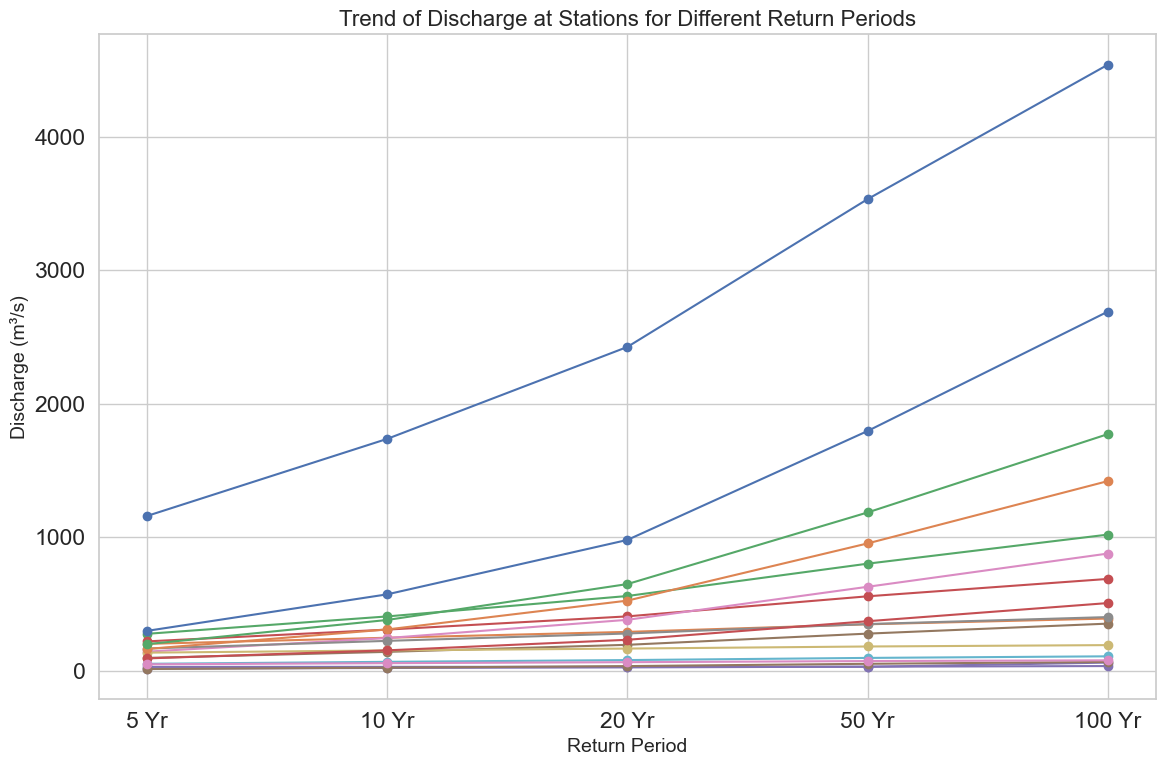

In [16]:
plt.figure(figsize=(12, 8))

for station in df['Station']:
    plt.plot(['5 Yr', '10 Yr', '20 Yr', '50 Yr','100 Yr'],
             df[df['Station'] == station].iloc[0, 1:], 
             marker='o', label=station)

plt.title('Trend of Discharge at Stations for Different Return Periods', fontsize=16)
plt.xlabel('Return Period', fontsize=14)
plt.ylabel('Discharge (m³/s)', fontsize=14)
# plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


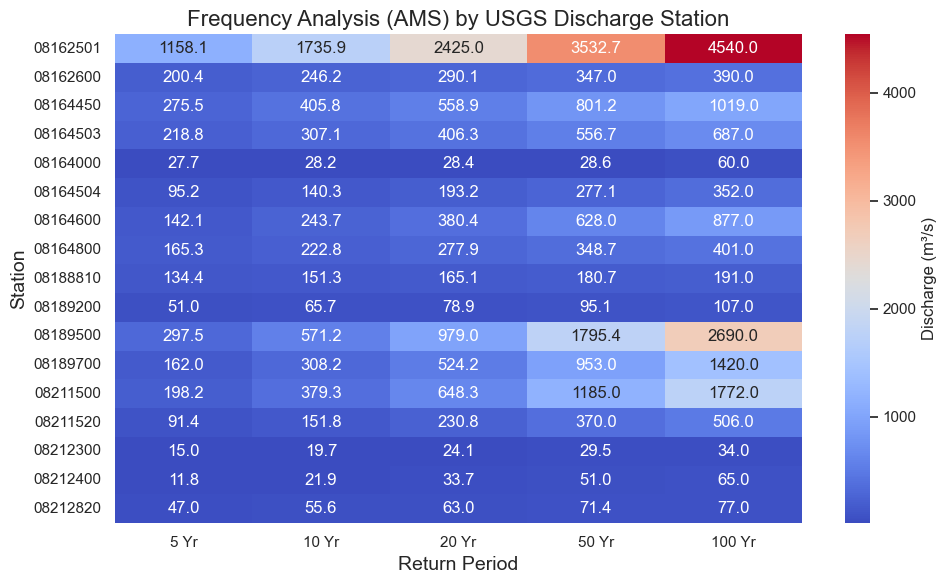

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.set_index('Station'), annot=True, cmap="coolwarm", fmt=".1f", cbar_kws={'label': 'Discharge (m³/s)'})

plt.title('Frequency Analysis (AMS) by USGS Discharge Station', fontsize=16)
plt.xlabel('Return Period', fontsize=14)
plt.ylabel('Station', fontsize=14)
plt.tight_layout()
plt.show()


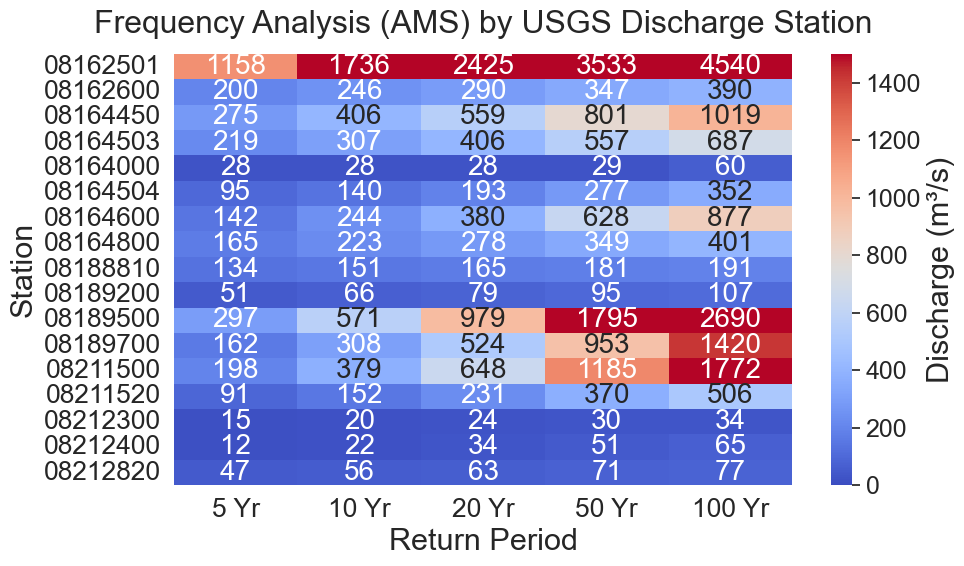

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Set font scale for seaborn (affects tick labels and annotations)
sns.set_context("notebook", font_scale=1.5)

# Create the heatmap
ax = sns.heatmap(
    df.set_index('Station'),
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    vmin=0, 
    vmax=1500, 
    cbar_kws={'label': 'Discharge (m³/s)'},
    annot_kws={"size": 20}, # Annotation font size
    
)

# Set title and axis labels with increased font size
ax.set_title('Frequency Analysis (AMS) by USGS Discharge Station', fontsize=23, pad=15)
ax.set_xlabel('Return Period', fontsize=22)
ax.set_ylabel('Station', fontsize=22)

# Adjust tick label font sizes
ax.tick_params(axis='both', labelsize=19)

# ---- Increase colorbar label font size ----
cbar = ax.collections[0].colorbar
cbar.set_label('Discharge (m³/s)', fontsize=22)
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()


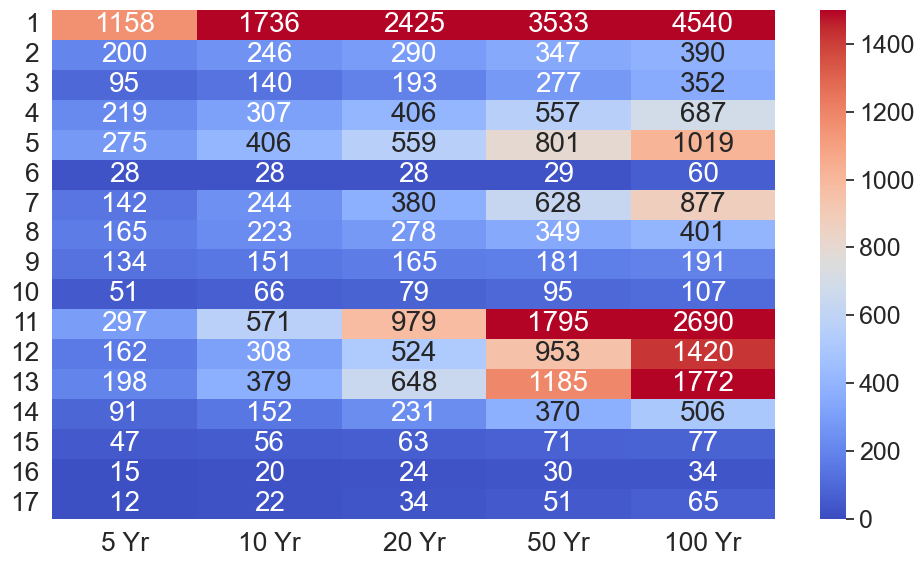

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Desired order from your table
station_order = [
    '08162501', '08162600', '08164504', '08164503', '08164450',
    '08164000', '08164600', '08164800', '08188810', '08189200',
    '08189500', '08189700', '08211500', '08211520', '08212820',
    '08212300', '08212400'
]

# Reorder dataframe
df_plot = df.set_index('Station').loc[station_order]
df_plot.index.name = None
# Create combined Given ID + Station ID labels
y_labels = [
    f"1",
    f"2",
    f"3",
    f"4",
    f"5",
    f"6",
    f"7",
    f"8",
    f"9",
    f"10",
    f"11",
    f"12",
    f"13",
    f"14",
    f"15",
    f"16",
    f"17"
]

plt.figure(figsize=(10, 6))

sns.set_context("notebook", font_scale=1.5)

ax = sns.heatmap(
    df_plot,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    vmin=0,
    vmax=1500,
    # cbar_kws={'label': 'Discharge (m³/s)'},
    annot_kws={"size": 20}
)

# Replace y-axis labels
ax.set_yticklabels(y_labels, rotation=0)

# ax.set_title('Frequency Analysis (AMS) by USGS Discharge Station', fontsize=23, pad=15)
# ax.set_xlabel('Return Period', fontsize=22)
# ax.set_ylabel('Given ID (Station ID)', fontsize=22)

ax.tick_params(axis='both', labelsize=19)

cbar = ax.collections[0].colorbar
# cbar.set_label('Discharge (m³/s)', fontsize=22)
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()